In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from pathlib import Path
import torch.nn as nn
import matplotlib.pyplot as plt

In [2]:
class RRDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples = []
        
        self.class_ai_to_idx = {"real": 0, "ai": 1}
        self.class_domain_to_idx = {"original": 0, "redigital": 1, "transfer": 2}

        for domain in self.class_domain_to_idx.keys():
            domain_path = self.root_dir / domain
            if not domain_path.exists(): continue
                
            for class_name in self.class_ai_to_idx.keys():
                class_path = domain_path / class_name
                for pattern in ("*.jpg", "*.png"):
                    for img_path in class_path.glob(pattern):
                        self.samples.append((img_path, self.class_ai_to_idx[class_name], self.class_domain_to_idx[domain]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label_ai, label_domain = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
            
        return image, {
            'label_ai': torch.tensor(label_ai, dtype=torch.long),
            'label_domain': torch.tensor(label_domain, dtype=torch.long)
        }

my_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

dataset = RRDataset(root_dir=Path(".")/"RRDataset_test"/"RRDataset_final", transform=my_transforms)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [ ]:
class FourierNetInput(nn.Module):
    def __init__(self):
        super(FourierNetInput, self).__init__()

    def forward(self, x):
        x_fft = torch.fft.fft2(x)
        x_fft_shifted = torch.fft.fftshift(x_fft)
        x_mag = torch.abs(x_fft_shifted)
        x_phase = torch.angle(x_fft_shifted)
        x_mag = torch.log(x_mag + 1) # Use the log in order to enphasise the differences between the magnitude values of each pixel
        return x_mag, x_phase

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.4308496].


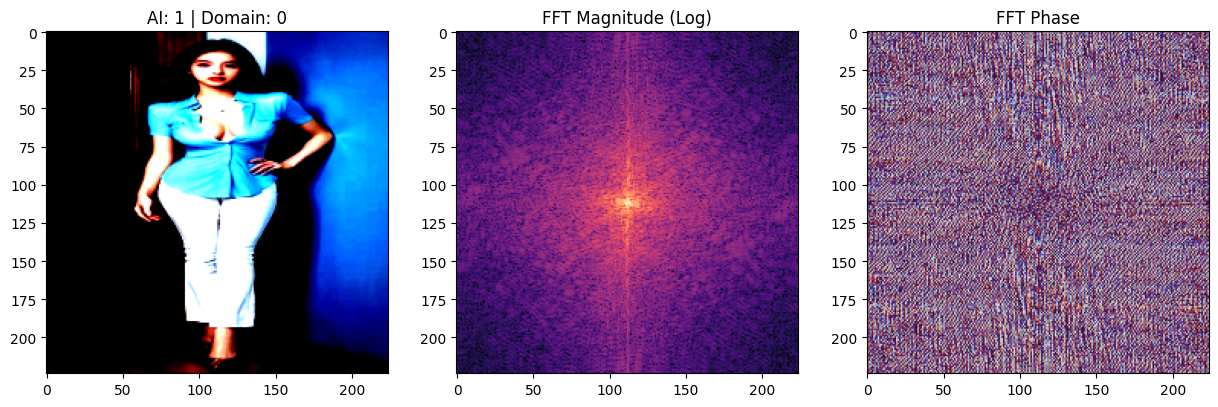

In [9]:
model = FourierNetInput()
images, labels = next(iter(dataloader))
mag, phase = model(images)

index = 0
img_to_show = images[index]
mag_to_show = mag[index]
phs_to_show = phase[index]

img_display = img_to_show.permute(1, 2, 0)
mag_display = mag_to_show[0] # show only the first channel of the magnitude 
phs_display = torch.mean(phs_to_show, dim=0)

label_ai_val = labels['label_ai'][index].item()
label_dom_val = labels['label_domain'][index].item()

plt.figure(figsize=(15, 5))

# Original image
plt.subplot(1, 3, 1)
plt.imshow(img_display)
plt.title(f"AI: {label_ai_val} | Domain: {label_dom_val}")

# Magnitude
plt.subplot(1, 3, 2)
plt.imshow(mag_display, cmap='magma')
plt.title("FFT Magnitude (Log)")

# Phase
plt.subplot(1, 3, 3)
plt.imshow(phs_display, cmap='twilight')
plt.title("FFT Phase")

plt.show()

In [ ]:
class FourierNet(nn.Module):
    def __init__(self, feature_dim=64):
        super(FourierNet, self).__init__()

        self.fourier_transform = FourierNetInput()
        
        # 6 input channels: 3 for the magnitude + 3 for the phase
        self.layers = nn.Sequential(
            self._make_layer(6, 32),  # Output: [B, 32, H/2, W/2]
            self._make_layer(32, 64), # Output: [B, 64, H/4, W/4]
            self._make_layer(64, 128) # Output: [B, 128, H/8, W/8]
        )
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1)) # each channel in input is summarized in a tensor of 1x1, namely a single value -> (B, 256, 1, 1)
        
        # 4. Fully Connected to obtain the informative vector (embedding)
        self.fc_embedding = nn.Sequential(
            nn.Linear(256, feature_dim),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        

    def _make_layer(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1), # zero padding (default of padding=1) -> output layer has the same dimension of the input
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # halve the spatial dimension of the input layer H/2, W/2
        )

    def forward(self, x):
        # Fourier Transform
        mag, phase = self.fourier_transform(x)
        
        # Concatenation of the magnitude and the phase along the first dimension (channels) 
        x_f = torch.cat((mag, phase), dim=1) # Shape: [B, 6, H, W]
        
        # Convolutional layers
        x_f = self.layers(x_f)
        
        # Embedding extraction
        x_f = self.global_pool(x_f)
        x_f = torch.flatten(x_f, 1)  # -> (B, 1, 256)
        
        embedding = self.fc_embedding(x_f)

        return embedding